# <centre> Beginner Friendly Tutorial
> Start your kaggle journey using this notebook and submit your first kaggle submission.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
%matplotlib inline

## Exploring data

In [2]:
train = pd.read_csv('../input/titanic/train.csv')
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## Data Descriptons

Survival: 0 = No, 1 = Yes

Pclass (Ticket class): 1 = 1st, 2 = 2nd, 3 = 3rd

Sex: Sex

Age: Age in years

SibSp: number of siblings/spouses aboard the Titanic

Parch: number of parents/children aboard the Titanic

Ticket: Ticket number

Fare: Passenger fare

Cabin: Cabin number

Embarked: Port of Embarkation, C = Cherbourg, Q = Queenstown, S = Southampton

In [4]:
train.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Kelly, Miss. Anna Katherine ""Annie Kate""",male,NaN,NaN,NaN,1601,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [5]:
train.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [6]:
train.shape

(891, 12)

### Check for missing data

In [7]:
train.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

<AxesSubplot:>

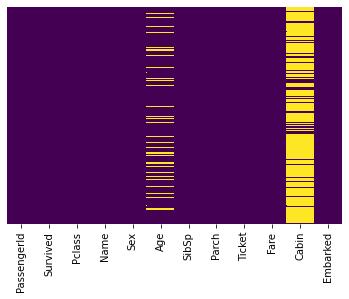

In [8]:
sb.heatmap(train.isnull(),yticklabels=False,cbar=False,cmap='viridis')

- We can clearly see missing values in column 'Age' & 'Cabin'.


In [9]:
train['Age'].isna().sum()

177

- Missing values in Age column is almost one quarter of our data which can be filled with average age.

#### Handling missing values

- So missing values in 'Age' column are filled with average age value
- However we can be smarter about this and check the average age by passenger class. 

<AxesSubplot:xlabel='Pclass', ylabel='Age'>

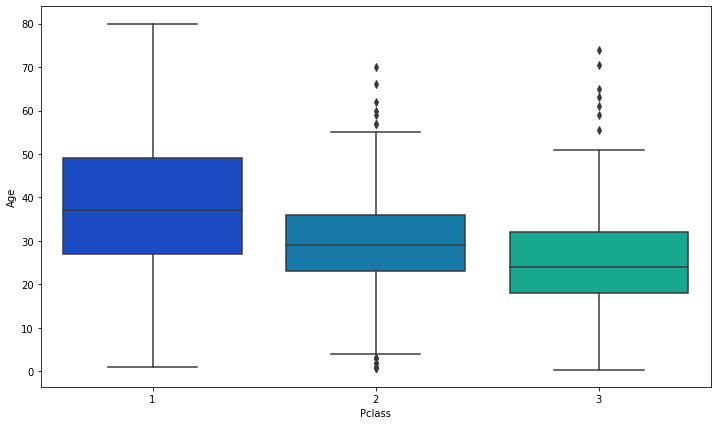

In [10]:
plt.figure(figsize=(12, 7))
sb.boxplot(x='Pclass',y='Age',data=train,palette='winter')

We can fill the missing values with average age in particular Class.
- Class 1 has average age value around 35.
- Class 2 has average age value around 30.
- Class 3 has average age value around 24.

In [11]:
def impute_age(cols):
    Age = cols[0]
    Pclass = cols[1]
    
    if pd.isnull(Age):

        if Pclass == 1:
            return 35

        elif Pclass == 2:
            return 30

        else:
            return 24

    else:
        return Age

In [12]:
train['Age'] = train[['Age','Pclass']].apply(impute_age,axis=1)

In [13]:
train['Age'].isna().sum()

0

In [14]:
train['Cabin'].isna().sum()

687

- 'Cabin' has most of values missing,so we won't be using this feature for modelling.

In [15]:
train['Embarked'].isna().sum()

2

- Since only 2 missing values are there in 'Embarked' column, we can drop it.

In [16]:
train = train.dropna(subset=['Embarked'])

In [17]:
train['Embarked'].isna().sum()

0

In [18]:
#Check if any duplicate rows in dataset
train.duplicated().sum()

0

## Feature Selection

In [19]:
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [20]:
train = train[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp',
       'Parch','Fare', 'Embarked']]

## Visualizing data and finding relationships

<AxesSubplot:xlabel='Survived', ylabel='count'>

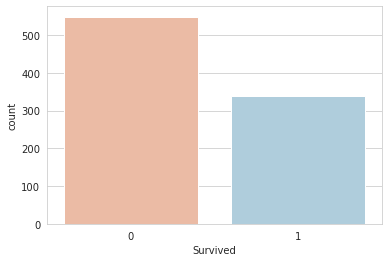

In [21]:
sb.set_style('whitegrid')
sb.countplot(x='Survived',data=train,palette='RdBu')

<AxesSubplot:xlabel='Survived', ylabel='count'>

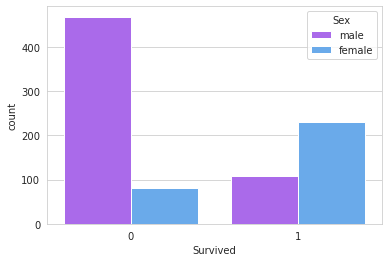

In [22]:
sb.set_style('whitegrid')
sb.countplot(x='Survived',hue='Sex',data=train,palette='cool_r')

<AxesSubplot:xlabel='Survived', ylabel='count'>

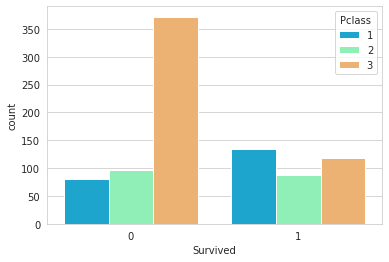

In [23]:
sb.set_style('whitegrid')
sb.countplot(x='Survived',hue='Pclass',data=train,palette='rainbow')

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function 

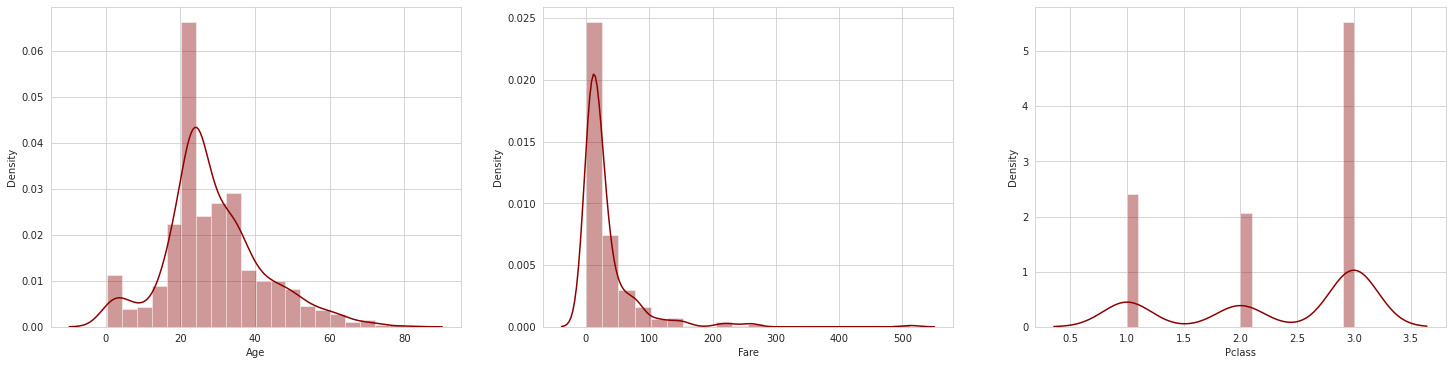

In [24]:
# Plots to see the distribution of the continuous features individually

plt.figure(figsize= (25,20))
plt.subplot(3,3,1)
sb.distplot(train['Age'],color='darkred',bins=20)


plt.subplot(3,3,2)
sb.distplot(train['Fare'],color='darkred',bins=20)

plt.subplot(3,3,3)
sb.distplot(train['Pclass'],color='darkred',bins=20)

plt.show()

<AxesSubplot:xlabel='SibSp', ylabel='count'>

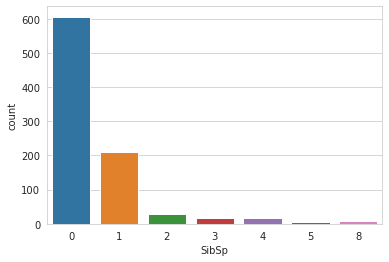

In [25]:
sb.countplot(x='SibSp',data=train)

Text(0, 0.5, 'Age')

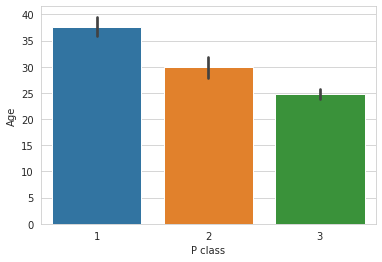

In [26]:
sb.barplot(y='Age',x='Pclass',data=train)
plt.xlabel('P class')
plt.ylabel('Age')

<AxesSubplot:xlabel='Embarked', ylabel='count'>

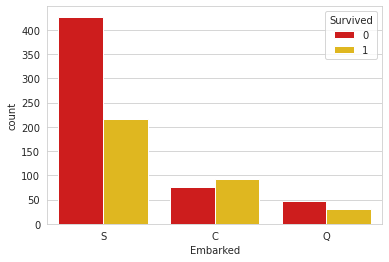

In [27]:
sb.countplot(x='Embarked',hue='Survived',data=train,palette='hot')

## Feature Encoding

###  Converting Categorical data

In [28]:
train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [29]:
# One hot encode the categorical columns
df_embarked_one_hot = pd.get_dummies(train['Embarked'], 
                                     prefix='embarked')

df_sex_one_hot = pd.get_dummies(train['Sex'], 
                                prefix='sex')

df_plcass_one_hot = pd.get_dummies(train['Pclass'], 
                                   prefix='pclass')

In [30]:
# Combine the one hot encoded columns with df_con_enc
train_one_hot = pd.concat([train, 
                        df_embarked_one_hot, 
                        df_sex_one_hot, 
                        df_plcass_one_hot], axis=1)
train_one_hot.head()



,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,embarked_C,embarked_Q,embarked_S,sex_female,sex_male,pclass_1,pclass_2,pclass_3
0,0,3,male,22.0,1,0,7.2500,S,0,0,1,0,1,0,0,1
1,1,1,female,38.0,1,0,71.2833,C,1,0,0,1,0,1,0,0
2,1,3,female,26.0,0,0,7.9250,S,0,0,1,1,0,0,0,1
3,1,1,female,35.0,1,0,53.1000,S,0,0,1,1,0,1,0,0
4,0,3,male,35.0,0,0,8.0500,S,0,0,1,0,1,0,0,1


In [31]:
# Drop the original categorical columns (because now they've been one hot encoded)
train = train_one_hot.drop(['Pclass', 'Sex', 'Embarked'], axis=1)
train.head()

,Survived,Age,SibSp,Parch,Fare,embarked_C,embarked_Q,embarked_S,sex_female,sex_male,pclass_1,pclass_2,pclass_3
0,0,22.0,1,0,7.2500,0,0,1,0,1,0,0,1
1,1,38.0,1,0,71.2833,1,0,0,1,0,1,0,0
2,1,26.0,0,0,7.9250,0,0,1,1,0,0,0,1
3,1,35.0,1,0,53.1000,0,0,1,1,0,1,0,0
4,0,35.0,0,0,8.0500,0,0,1,0,1,0,0,1


In [32]:
train.shape

(889, 13)

## Building Machine Learning Models

### Split the data into train and test

In [33]:
from sklearn.model_selection import train_test_split

In [34]:
X = train.drop('Survived',axis=1)
Y = train['Survived']

In [35]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y)

In [36]:
X_train.shape, Y_train.shape

((666, 12), (666,))

## Train Models

## Gradient boosting Classifier

In [37]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

In [38]:
gbc = GradientBoostingClassifier()

In [39]:
gbc.fit(X_train,Y_train)

GradientBoostingClassifier()

In [40]:
Y_pred = gbc.predict(X_test)

In [41]:
gbc_acc = accuracy_score(Y_pred, Y_test)
print("Accuracy for Gradient boosting Classifier : ",gbc_acc)

Accuracy for Gradient boosting Classifier :  0.8385650224215246


## Logistic Regression

In [42]:
from sklearn.linear_model import LogisticRegression

In [43]:
lgr = LogisticRegression()

In [44]:
lgr.fit(X_train,Y_train)

/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:764: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)


LogisticRegression()

In [45]:
Y_pred = lgr.predict(X_test)

In [46]:
lgr_acc = accuracy_score(Y_pred,Y_test)
print('Accuracy score for Logistic Regression: ',lgr_acc)

Accuracy score for Logistic Regression:  0.8251121076233184


## Naive Bayes

In [47]:
from sklearn.naive_bayes import GaussianNB 
gnb = GaussianNB() 
gnb.fit(X_train, Y_train) 

GaussianNB()

In [48]:
Y_pred = gnb.predict(X_test)

In [49]:
gnb_acc = accuracy_score(Y_pred,Y_test)
print('Accuracy score for Naive Bayes: ',gnb_acc)

Accuracy score for Naive Bayes:  0.820627802690583


## Decision Tree

In [50]:
from sklearn.tree import DecisionTreeClassifier
dtc= DecisionTreeClassifier(criterion='entropy', random_state=0)  
dtc.fit(X_train,Y_train)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [51]:
Y_pred = dtc.predict(X_test)

In [52]:
dtc_acc = accuracy_score(Y_pred,Y_test)
print('Accuracy score for Decision Tree Classifier: ',dtc_acc)

Accuracy score for Decision Tree Classifier:  0.7892376681614349


## Random Forest

In [53]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier()
rfc.fit(X_train,Y_train)

RandomForestClassifier()

In [54]:
Y_pred = rfc.predict(X_test)

In [55]:
rfc_acc = accuracy_score(Y_pred,Y_test)
print('Accuracy score for Random Forest Classifier: ',rfc_acc)

Accuracy score for Random Forest Classifier:  0.8161434977578476


## SVM 

In [56]:
from sklearn.svm import SVC
svc = SVC()
svc.fit(X_train,Y_train)

SVC()

In [57]:
Y_pred = svc.predict(X_test)

In [58]:
svc_acc = accuracy_score(Y_pred,Y_test)
print('Accuracy score for SVM: ',svc_acc)

Accuracy score for SVM:  0.6367713004484304


## KNN

In [59]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train,Y_train)

KNeighborsClassifier()

In [60]:
Y_pred = knn.predict(X_test)

In [61]:
knn_acc = accuracy_score(Y_pred,Y_test)
print('Accuracy score for KNN: ',knn_acc)

Accuracy score for KNN:  0.7085201793721974


#### Make a dataframe for comparing our Machine Learning Models

In [62]:
models = pd.DataFrame({
    'Model': ['KNN', 'Logistic Regression', 'Naive Bayes', 
               'SVC', 'Random Forest',
              'Decision Tree', 'Gradient Boosting Classifier'],
    'Score': [
        knn_acc, 
        lgr_acc,  
        gnb_acc, 
        svc_acc,
        rfc_acc,
        dtc_acc,
        gbc_acc,
    ]})
print("--- Accuracy Scores---")
models.sort_values(by='Score', ascending=False)

--- Accuracy Scores---


,Model,Score
6,Gradient Boosting Classifier,0.838565
1,Logistic Regression,0.825112
2,Naive Bayes,0.820628
4,Random Forest,0.816143
5,Decision Tree,0.789238
0,KNN,0.708520
3,SVC,0.636771


- We gained maximum accuracy score from "Gradient Boosting Classifier",so we will choose it for our final test data.

## Test Model on test data

In [63]:
test = pd.read_csv('../input/titanic/train.csv')
test.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [64]:
test.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [65]:
test['Age'] = test[['Age','Pclass']].apply(impute_age,axis=1)

In [66]:
test['Fare'] = test['Fare'].fillna(test['Fare'].mean())

In [67]:
test.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Feature selection in test data

In [68]:
test.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [69]:
test = test[[ 'PassengerId','Pclass','Sex', 'Age', 'SibSp', 'Parch','Fare','Embarked']]
test.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,3,male,22.0,1,0,7.2500,S
1,2,1,female,38.0,1,0,71.2833,C
2,3,3,female,26.0,0,0,7.9250,S
3,4,1,female,35.0,1,0,53.1000,S
4,5,3,male,35.0,0,0,8.0500,S


#### Convert categorical test data into numerical data

In [70]:
# One hot encode the categorical columns
df_embarked_one_hot_t = pd.get_dummies(test['Embarked'], 
                                     prefix='embarked')

df_sex_one_hot_t = pd.get_dummies(test['Sex'], 
                                prefix='sex')

df_plcass_one_hot_t = pd.get_dummies(test['Pclass'], 
                                   prefix='pclass')

In [71]:
# Combine the one hot encoded columns with df_con_enc
test_one_hot = pd.concat([test, 
                        df_embarked_one_hot_t, 
                        df_sex_one_hot_t, 
                        df_plcass_one_hot_t], axis=1)


In [72]:
# Drop the original categorical columns (because now they've been one hot encoded)
test = test_one_hot.drop(['Pclass', 'Sex', 'Embarked'], axis=1)
test.head()

,PassengerId,Age,SibSp,Parch,Fare,embarked_C,embarked_Q,embarked_S,sex_female,sex_male,pclass_1,pclass_2,pclass_3
0,1,22.0,1,0,7.2500,0,0,1,0,1,0,0,1
1,2,38.0,1,0,71.2833,1,0,0,1,0,1,0,0
2,3,26.0,0,0,7.9250,0,0,1,1,0,0,0,1
3,4,35.0,1,0,53.1000,0,0,1,1,0,1,0,0
4,5,35.0,0,0,8.0500,0,0,1,0,1,0,0,1


In [73]:
test.columns

Index(['PassengerId', 'Age', 'SibSp', 'Parch', 'Fare', 'embarked_C',
       'embarked_Q', 'embarked_S', 'sex_female', 'sex_male', 'pclass_1',
       'pclass_2', 'pclass_3'],
      dtype='object')

In [74]:
test.shape

(891, 13)

### Assign train and test data

In [75]:
X_train = train.drop("Survived", axis=1)
Y_train = train["Survived"]
X_test  = test.drop("PassengerId",axis=1)
X_train.shape, Y_train.shape, X_test.shape

((889, 12), (889,), (891, 12))

## Gradient Boosting Classifier

In [76]:
gbc.fit(X_train, Y_train)
Y_pred_test = gbc.predict(X_test)

In [77]:
acc = round(gbc.score(X_train, Y_train) * 100, 2)
print("Accuracy Score for Gradient Boosting Classifier on test data: ",acc)

Accuracy Score for Gradient Boosting Classifier on test data:  89.09


In [78]:
#Check for final test result columns
Y_pred_test.shape

(891,)

## Submission

In [79]:
# Create a submisison dataframe and append the relevant columns
submission = pd.DataFrame()
submission['PassengerId'] = test['PassengerId']
submission['Survived'] = Y_pred_test # our model predictions on the test dataset
submission.head()

,PassengerId,Survived
0,1,0
1,2,1
2,3,0
3,4,1
4,5,0


In [80]:
submission.shape

(891, 2)

### Convert dataframe into csv file for submission

In [81]:
submission.to_csv(r'C:\Users\hp\Desktop\Kaggle\submission.csv',index=False)

In [82]:
# Check if we file is converted in csv and read it.
check = pd.read_csv(r'C:\Users\hp\Desktop\Kaggle\submission.csv')
check.head()

,PassengerId,Survived
0,1,0
1,2,1
2,3,0
3,4,1
4,5,0
